In [ ]:
import sympy as sp                    # Importa SymPy para realizar cálculo simbólico
from pyr0compute import R0Model       # Importa la clase R0Model desde el paquete pyr0compute
sp.init_printing()                    # Activa la impresión matemática formateada de SymPy
from IPython.display import Markdown, display # Importa Markdown y display para mostrar resultados en formato Markdown en Jupyter Notebook

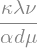

In [7]:
m1 = R0Model("""
    dE/dt = lambda - d*E - kappa*E*V
    dI/dt = kappa*E*V - alpha*I
    dV/dt = nu*I - mu*V 
""", infected=["I", "V"])

m1.R0

In [ ]:
display(Markdown(m1.report_latex("markdown")))

## pyR0compute: next-generation matrix method

**Variables:** $E, I, V$  
**Infected compartments:** $I, V$  
**Parameters (detected automatically):** $\alpha, d, \kappa, \lambda, \mu, \nu$

### Model

$$
\begin{aligned}
\frac{dE}{dt} &= - E V \kappa - E d + \lambda \\
\frac{dI}{dt} &= E V \kappa - I \alpha \\
\frac{dV}{dt} &= I \nu - V \mu
\end{aligned}
$$

### New-infection terms (automatic)

$$
\begin{aligned}
\mathcal{F}_{I} &= E V \kappa \\
\mathcal{F}_{V} &= 0
\end{aligned}
$$

### Term classification

| Equation | Term | Class | Reason |
|---|---|:---:|---|
| $dI/dt$ | $- I \alpha$ | $\mathcal{V}$ | negative term |
| $dI/dt$ | $E V \kappa$ | $\mathcal{F}$ | transfer from uninfected E |
| $dV/dt$ | $I \nu$ | $\mathcal{V}$ | transfer from infected I |
| $dV/dt$ | $- V \mu$ | $\mathcal{V}$ | negative term |

### Transition terms

$$
\begin{aligned}
\mathcal{V}_{I} &= I \alpha \\
\mathcal{V}_{V} &= - I \nu + V \mu
\end{aligned}
$$

### Disease-free equilibrium

$$
\begin{aligned}
E &= \frac{\lambda}{d} \\
I &= 0 \\
V &= 0
\end{aligned}
$$

### Next-generation matrix

$$
\begin{aligned}
F &= \begin{bmatrix}0 & \frac{\kappa \lambda}{d}\\0 & 0\end{bmatrix} \\
V &= \begin{bmatrix}\alpha & 0\\- \nu & \mu\end{bmatrix} \\
K = F V^{-1} &= \begin{bmatrix}\frac{\kappa \lambda \nu}{\alpha d \mu} & \frac{\kappa \lambda}{d \mu}\\0 & 0\end{bmatrix}
\end{aligned}
$$

Only $I$ receive new infections, so $\mathcal{R}_0$ is the spectral radius of the next-generation matrix with small domain:

$$
\begin{aligned}
K_{\text{small}} &= \begin{bmatrix}\frac{\kappa \lambda \nu}{\alpha d \mu}\end{bmatrix}
\end{aligned}
$$

### Basic reproduction number

$$
\begin{aligned}
\mathcal{R}_0 = \rho\left(F V^{-1}\right) &= \frac{\kappa \lambda \nu}{\alpha d \mu}
\end{aligned}
$$

In [13]:
print(m1.report_latex())

\section*{pyR0compute: next-generation matrix method}

\textbf{Variables:} $E, I, V$ \\
\textbf{Infected compartments:} $I, V$ \\
\textbf{Parameters (detected automatically):} $\alpha, d, \kappa, \lambda, \mu, \nu$

\subsection*{Model}

\begin{align*}
\frac{dE}{dt} &= - E V \kappa - E d + \lambda \\
\frac{dI}{dt} &= E V \kappa - I \alpha \\
\frac{dV}{dt} &= I \nu - V \mu
\end{align*}

\subsection*{New-infection terms (automatic)}

\begin{align*}
\mathcal{F}_{I} &= E V \kappa \\
\mathcal{F}_{V} &= 0
\end{align*}

\subsection*{Term classification}

\begin{tabular}{llcl}
\hline
Equation & Term & Class & Reason \\
\hline
$dI/dt$ & $- I \alpha$ & $\mathcal{V}$ & negative term \\
$dI/dt$ & $E V \kappa$ & $\mathcal{F}$ & transfer from uninfected E \\
$dV/dt$ & $I \nu$ & $\mathcal{V}$ & transfer from infected I \\
$dV/dt$ & $- V \mu$ & $\mathcal{V}$ & negative term \\
\hline
\end{tabular}

\subsection*{Transition terms}

\begin{align*}
\mathcal{V}_{I} &= I \alpha \\
\mathcal{V}_{V} &= - I \nu 

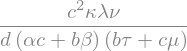

In [16]:
from pyr0compute import R0Model

m2 = R0Model("""
    dI/dt = kappa*E*V - alpha*I - beta*T_h*I
    dV/dt = nu*I - mu*V - tau*T_h*V
    dE/dt = lambda - d*E - kappa*E*V
    dT_h/dt = b - c*T_h + gamma*I*T_h
""", infected=["I", "V"])

m2.R0

In [17]:
display(Markdown(m2.report_latex("markdown")))

## pyR0compute: next-generation matrix method

**Variables:** $I, V, E, T_{h}$  
**Infected compartments:** $I, V$  
**Parameters (detected automatically):** $\alpha, b, \beta, c, d, \gamma, \kappa, \lambda, \mu, \nu, \tau$

### Model

$$
\begin{aligned}
\frac{dI}{dt} &= E V \kappa - I T_{h} \beta - I \alpha \\
\frac{dV}{dt} &= I \nu - T_{h} V \tau - V \mu \\
\frac{dE}{dt} &= - E V \kappa - E d + \lambda \\
\frac{dT_{h}}{dt} &= I T_{h} \gamma - T_{h} c + b
\end{aligned}
$$

### New-infection terms (automatic)

$$
\begin{aligned}
\mathcal{F}_{I} &= E V \kappa \\
\mathcal{F}_{V} &= 0
\end{aligned}
$$

### Term classification

| Equation | Term | Class | Reason |
|---|---|:---:|---|
| $dI/dt$ | $- I \alpha$ | $\mathcal{V}$ | negative term |
| $dI/dt$ | $E V \kappa$ | $\mathcal{F}$ | transfer from uninfected E |
| $dI/dt$ | $- I T_{h} \beta$ | $\mathcal{V}$ | negative term |
| $dV/dt$ | $I \nu$ | $\mathcal{V}$ | transfer from infected I |
| $dV/dt$ | $- V \mu$ | $\mathcal{V}$ | negative term |
| $dV/dt$ | $- T_{h} V \tau$ | $\mathcal{V}$ | negative term |

### Transition terms

$$
\begin{aligned}
\mathcal{V}_{I} &= I T_{h} \beta + I \alpha \\
\mathcal{V}_{V} &= - I \nu + T_{h} V \tau + V \mu
\end{aligned}
$$

### Disease-free equilibrium

$$
\begin{aligned}
I &= 0 \\
V &= 0 \\
E &= \frac{\lambda}{d} \\
T_{h} &= \frac{b}{c}
\end{aligned}
$$

### Next-generation matrix

$$
\begin{aligned}
F &= \begin{bmatrix}0 & \frac{\kappa \lambda}{d}\\0 & 0\end{bmatrix} \\
V &= \begin{bmatrix}\frac{\alpha c + b \beta}{c} & 0\\- \nu & \frac{b \tau + c \mu}{c}\end{bmatrix} \\
K = F V^{-1} &= \begin{bmatrix}\frac{c^{2} \kappa \lambda \nu}{d \left(\alpha c + b \beta\right) \left(b \tau + c \mu\right)} & \frac{c \kappa \lambda}{d \left(b \tau + c \mu\right)}\\0 & 0\end{bmatrix}
\end{aligned}
$$

Only $I$ receive new infections, so $\mathcal{R}_0$ is the spectral radius of the next-generation matrix with small domain:

$$
\begin{aligned}
K_{\text{small}} &= \begin{bmatrix}\frac{c^{2} \kappa \lambda \nu}{d \left(\alpha c + b \beta\right) \left(b \tau + c \mu\right)}\end{bmatrix}
\end{aligned}
$$

### Basic reproduction number

$$
\begin{aligned}
\mathcal{R}_0 = \rho\left(F V^{-1}\right) &= \frac{c^{2} \kappa \lambda \nu}{d \left(\alpha c + b \beta\right) \left(b \tau + c \mu\right)}
\end{aligned}
$$